## 1. Configuración e Importación de Librerías

In [ ]:
# Librerías estándar
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Agregar directorio src al path
sys.path.append(str(Path.cwd().parent / 'src'))

# Librerías de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Algoritmos de clustering
from sklearn.cluster import KMeans, DBSCAN

# Métricas de evaluación
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score,
    silhouette_samples
)

# Utilidades personalizadas
from utils import get_cluster_statistics

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


## 2. Carga de Datos

In [ ]:
# Cargar datos normalizados (para clustering)
data_path = Path.cwd().parent / 'data' / 'processed_data_scaled.csv'
df = pd.read_csv(data_path)

# Cargar datos con features para caracterización
data_featured_path = Path.cwd().parent / 'data' / 'processed_data_featured.csv'
df_featured = pd.read_csv(data_featured_path)

# Separar features de columnas contextuales
context_cols = ['FECHA', 'HORA', 'INTERVALO', 'CATEGORIA']
feature_cols = [col for col in df.columns if col not in context_cols]

X = df[feature_cols].values

# Cargar datos reducidos (PCA y UMAP)
pca_2d_path = Path.cwd().parent / 'data' / 'pca_2d.csv'
umap_2d_path = Path.cwd().parent / 'data' / 'umap_2d.csv'

df_pca_2d = pd.read_csv(pca_2d_path)
df_umap_2d = pd.read_csv(umap_2d_path)

print(f"Datos cargados exitosamente")
print(f"  Dimensiones originales: {X.shape[0]:,} observaciones × {X.shape[1]} features")
print(f"  PCA 2D: {df_pca_2d.shape}")
print(f"  UMAP 2D: {df_umap_2d.shape}")

✓ Datos cargados exitosamente
  Dimensiones originales: 2,881 observaciones × 46 features
  PCA 2D: (2881, 5)
  UMAP 2D: (2881, 5)


## 3. K-means Clustering

### 3.1. Determinación del Número Óptimo de Clusters (Método del Codo + Silhouette)

In [22]:
# Evaluar diferentes valores de k
k_range = range(2, 11)
inertias = []
silhouettes = []
davies_bouldin = []
calinski_harabasz = []

print("Evaluando K-means para diferentes valores de k...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    davies_bouldin.append(davies_bouldin_score(X, labels))
    calinski_harabasz.append(calinski_harabasz_score(X, labels))
    
    print(f"  k={k}: Silhouette={silhouettes[-1]:.4f}, DB={davies_bouldin[-1]:.4f}, CH={calinski_harabasz[-1]:.2f}")

print("\n✓ Evaluación completada")

Evaluando K-means para diferentes valores de k...
  k=2: Silhouette=0.3065, DB=1.3579, CH=1297.43
  k=2: Silhouette=0.3065, DB=1.3579, CH=1297.43
  k=3: Silhouette=0.2382, DB=1.4238, CH=943.82
  k=3: Silhouette=0.2382, DB=1.4238, CH=943.82
  k=4: Silhouette=0.2289, DB=1.6070, CH=844.58
  k=4: Silhouette=0.2289, DB=1.6070, CH=844.58
  k=5: Silhouette=0.2408, DB=1.4811, CH=756.53
  k=5: Silhouette=0.2408, DB=1.4811, CH=756.53
  k=6: Silhouette=0.2363, DB=1.4090, CH=717.91
  k=7: Silhouette=0.2388, DB=1.2117, CH=712.78
  k=6: Silhouette=0.2363, DB=1.4090, CH=717.91
  k=7: Silhouette=0.2388, DB=1.2117, CH=712.78
  k=8: Silhouette=0.2372, DB=1.2730, CH=686.55
  k=8: Silhouette=0.2372, DB=1.2730, CH=686.55
  k=9: Silhouette=0.2468, DB=1.2327, CH=655.54
  k=9: Silhouette=0.2468, DB=1.2327, CH=655.54
  k=10: Silhouette=0.2495, DB=1.1543, CH=643.10

✓ Evaluación completada
  k=10: Silhouette=0.2495, DB=1.1543, CH=643.10

✓ Evaluación completada


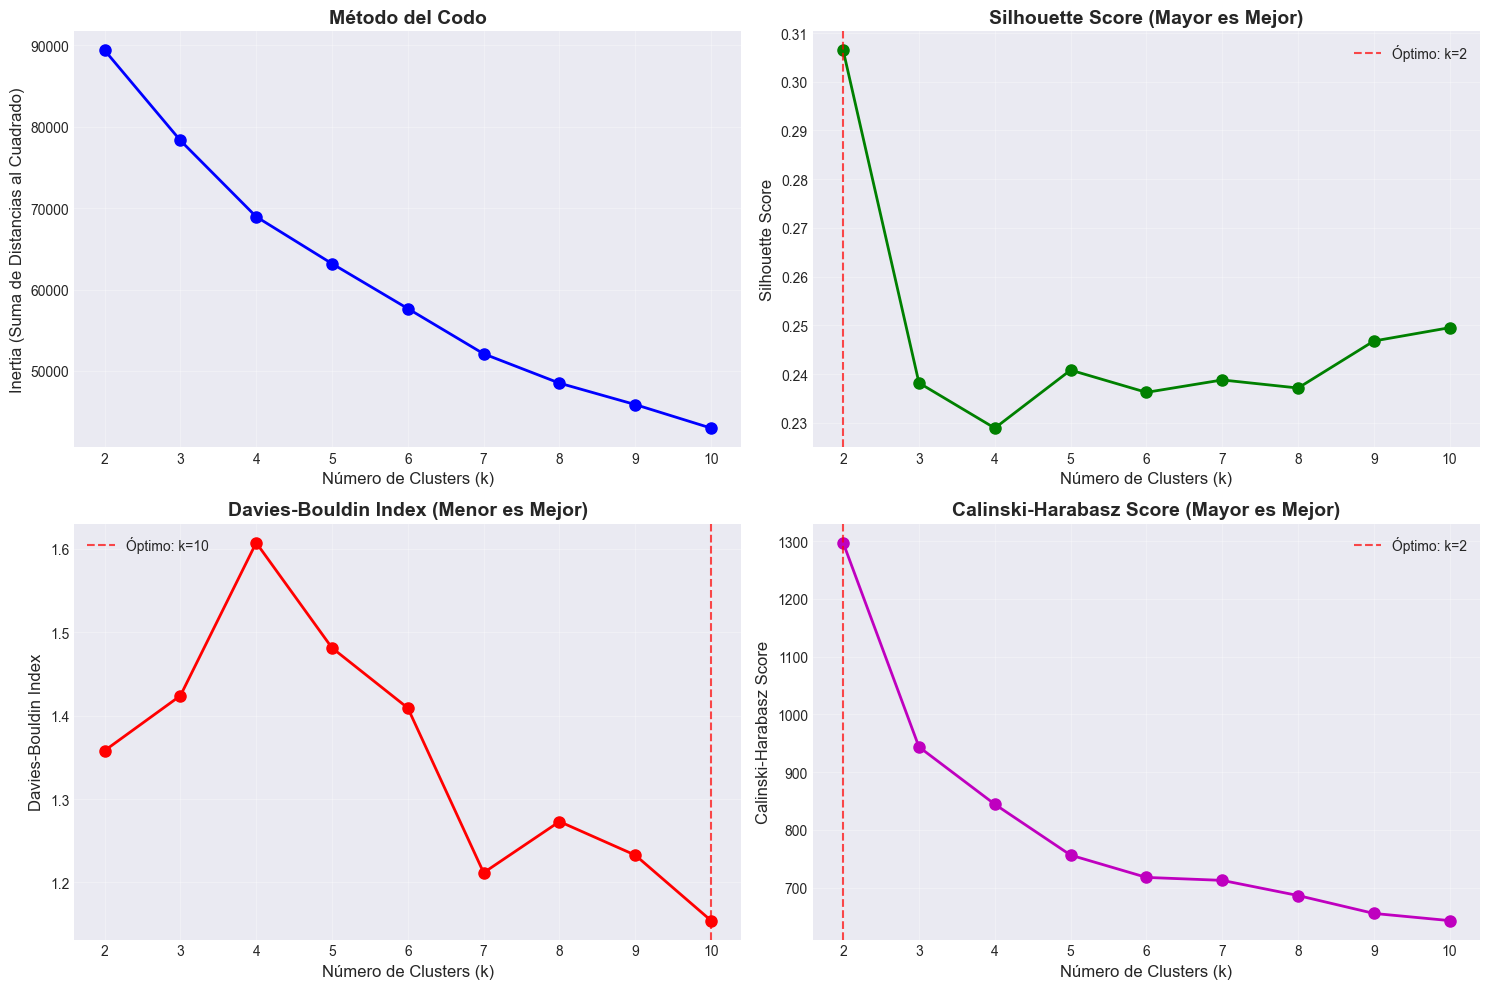


Recomendaciones por métrica:
  Silhouette Score: k=2
  Davies-Bouldin Index: k=10
  Calinski-Harabasz Score: k=2


In [23]:
# Visualizar métricas de evaluación
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Método del codo (Inertia)
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia (Suma de Distancias al Cuadrado)', fontsize=12)
axes[0, 0].set_title('Método del Codo', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score (mayor es mejor)
axes[0, 1].plot(k_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (Mayor es Mejor)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
best_k_sil = k_range[np.argmax(silhouettes)]
axes[0, 1].axvline(best_k_sil, color='r', linestyle='--', alpha=0.7, label=f'Óptimo: k={best_k_sil}')
axes[0, 1].legend()

# Davies-Bouldin Index (menor es mejor)
axes[1, 0].plot(k_range, davies_bouldin, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index (Menor es Mejor)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
best_k_db = k_range[np.argmin(davies_bouldin)]
axes[1, 0].axvline(best_k_db, color='r', linestyle='--', alpha=0.7, label=f'Óptimo: k={best_k_db}')
axes[1, 0].legend()

# Calinski-Harabasz Score (mayor es mejor)
axes[1, 1].plot(k_range, calinski_harabasz, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 1].set_title('Calinski-Harabasz Score (Mayor es Mejor)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
best_k_ch = k_range[np.argmax(calinski_harabasz)]
axes[1, 1].axvline(best_k_ch, color='r', linestyle='--', alpha=0.7, label=f'Óptimo: k={best_k_ch}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../images/kmeans_elbow_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nRecomendaciones por métrica:")
print(f"  Silhouette Score: k={best_k_sil}")
print(f"  Davies-Bouldin Index: k={best_k_db}")
print(f"  Calinski-Harabasz Score: k={best_k_ch}")

### 3.2. Aplicar K-means con k Óptimo

In [24]:
# Seleccionar k óptimo basado en las métricas
# Usaremos el valor sugerido por Silhouette Score
optimal_k = best_k_sil

print(f"Aplicando K-means con k={optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=300)
kmeans_labels = kmeans_final.fit_predict(X)

# Calcular métricas finales
kmeans_silhouette = silhouette_score(X, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X, kmeans_labels)
kmeans_calinski_harabasz = calinski_harabasz_score(X, kmeans_labels)

print(f"\n✓ K-means completado con k={optimal_k}")
print(f"\nMétricas de Calidad:")
print(f"  Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Score: {kmeans_calinski_harabasz:.2f}")
print(f"\nDistribución de Clusters:")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count:,} observaciones ({count/len(kmeans_labels)*100:.1f}%)")

Aplicando K-means con k=2...

✓ K-means completado con k=2

Métricas de Calidad:
  Silhouette Score: 0.3065
  Davies-Bouldin Index: 1.3579
  Calinski-Harabasz Score: 1297.43

Distribución de Clusters:
  Cluster 0: 1,508 observaciones (52.3%)
  Cluster 1: 1,373 observaciones (47.7%)

✓ K-means completado con k=2

Métricas de Calidad:
  Silhouette Score: 0.3065
  Davies-Bouldin Index: 1.3579
  Calinski-Harabasz Score: 1297.43

Distribución de Clusters:
  Cluster 0: 1,508 observaciones (52.3%)
  Cluster 1: 1,373 observaciones (47.7%)


### 3.3. Visualización de Clusters K-means

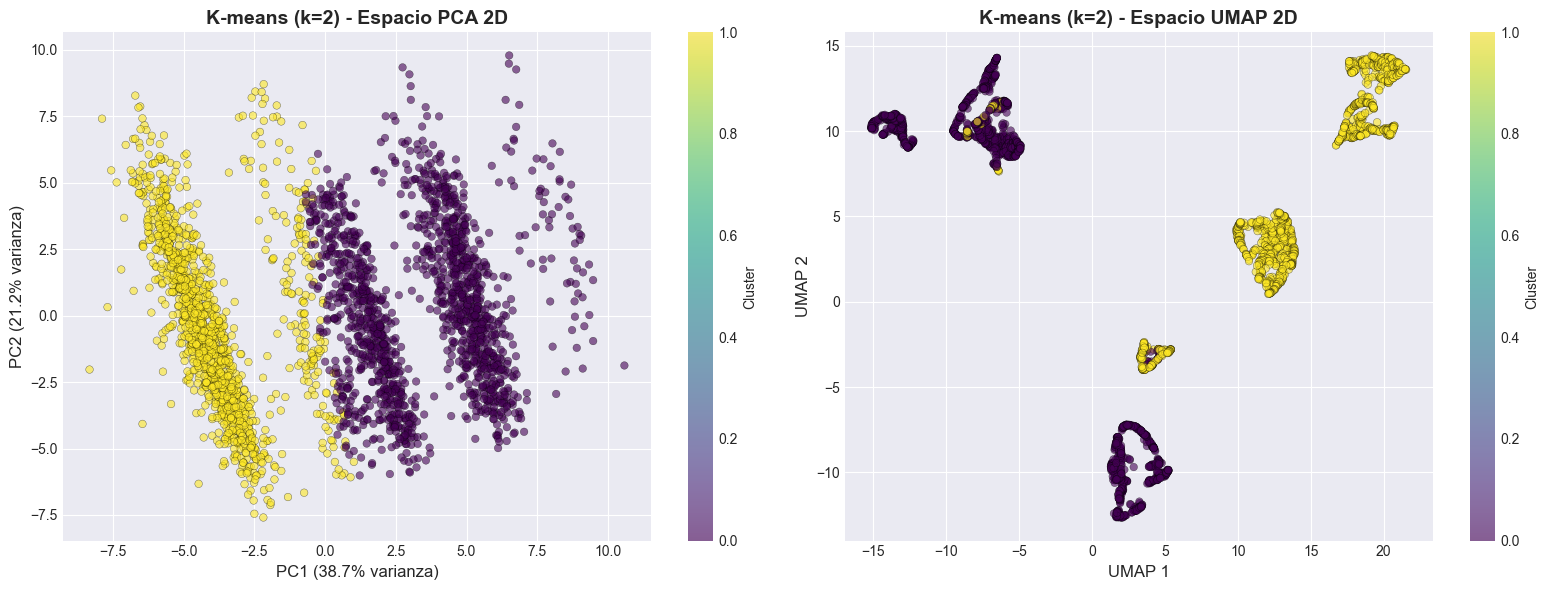

In [25]:
# Visualizar en PCA 2D y UMAP 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA 2D
scatter1 = axes[0].scatter(df_pca_2d['PC1'], df_pca_2d['PC2'], 
                          c=kmeans_labels, cmap='viridis', 
                          alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
axes[0].set_xlabel('PC1 (38.7% varianza)', fontsize=12)
axes[0].set_ylabel('PC2 (21.2% varianza)', fontsize=12)
axes[0].set_title(f'K-means (k={optimal_k}) - Espacio PCA 2D', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# UMAP 2D
scatter2 = axes[1].scatter(df_umap_2d['UMAP1'], df_umap_2d['UMAP2'], 
                          c=kmeans_labels, cmap='viridis', 
                          alpha=0.6, s=30, edgecolors='k', linewidth=0.3)
axes[1].set_xlabel('UMAP 1', fontsize=12)
axes[1].set_ylabel('UMAP 2', fontsize=12)
axes[1].set_title(f'K-means (k={optimal_k}) - Espacio UMAP 2D', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('../images/kmeans_clusters_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.4. Caracterización de Clusters K-means

In [26]:
# Añadir labels a los datos con features
df_featured['Cluster_KMeans'] = kmeans_labels

# Caracterizar cada cluster
print("="*80)
print("CARACTERIZACIÓN DE CLUSTERS K-MEANS")
print("="*80)

# Variables clave para caracterización
key_vars = ['KWHD', 'KVAD', 'FACTOR_POTENCIA', 'VOLTAJE_PROM', 'CORRIENTE_PROM', 
            'THD_CORRIENTE_PROMEDIO', 'DESBALANCE_CORRIENTE', 'HORA']

for cluster_id in range(optimal_k):
    cluster_data = df_featured[df_featured['Cluster_KMeans'] == cluster_id]
    n_obs = len(cluster_data)
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} (n={n_obs:,}, {n_obs/len(df_featured)*100:.1f}%)")
    print(f"{'='*80}")
    
    # Estadísticas de variables clave
    for var in key_vars:
        if var in cluster_data.columns:
            mean_val = cluster_data[var].mean()
            std_val = cluster_data[var].std()
            print(f"  {var:30s}: {mean_val:10.2f} ± {std_val:8.2f}")
    
    # Distribución temporal
    hora_dist = cluster_data['HORA'].value_counts().sort_index()
    hora_pico = hora_dist.idxmax()
    print(f"\n  Hora con más observaciones: {hora_pico}:00 ({hora_dist[hora_pico]} obs)")
    
    # Día de la semana
    if 'DIA_SEMANA' in cluster_data.columns:
        dia_dist = cluster_data['DIA_SEMANA'].value_counts()
        print(f"  Día más frecuente: Día {dia_dist.idxmax()} ({dia_dist.max()} obs)")

CARACTERIZACIÓN DE CLUSTERS K-MEANS

CLUSTER 0 (n=1,508, 52.3%)
  KWHD                          :      21.03 ±     4.58
  KVAD                          :      85.56 ±    19.07
  FACTOR_POTENCIA               :       0.98 ±     0.02
  VOLTAJE_PROM                  :   13357.22 ±    78.29
  CORRIENTE_PROM                :       1.43 ±     0.48
  THD_CORRIENTE_PROMEDIO        :       0.16 ±     0.05
  DESBALANCE_CORRIENTE          :       0.16 ±     0.22
  HORA                          :      11.81 ±     4.91

  Hora con más observaciones: 8:00 (108 obs)
  Día más frecuente: Día 1 (311 obs)

CLUSTER 1 (n=1,373, 47.7%)
  KWHD                          :       6.96 ±     2.00
  KVAD                          :      27.95 ±     7.89
  FACTOR_POTENCIA               :       0.99 ±     0.07
  VOLTAJE_PROM                  :   13392.94 ±    85.02
  CORRIENTE_PROM                :       0.06 ±     0.18
  THD_CORRIENTE_PROMEDIO        :       0.36 ±     0.08
  DESBALANCE_CORRIENTE          :       0

## 4. DBSCAN Clustering

### 4.1. Determinación de Hiperparámetros (eps y min_samples)

min_samples sugerido (2 * dim): 92

Calculando k-distance graph...


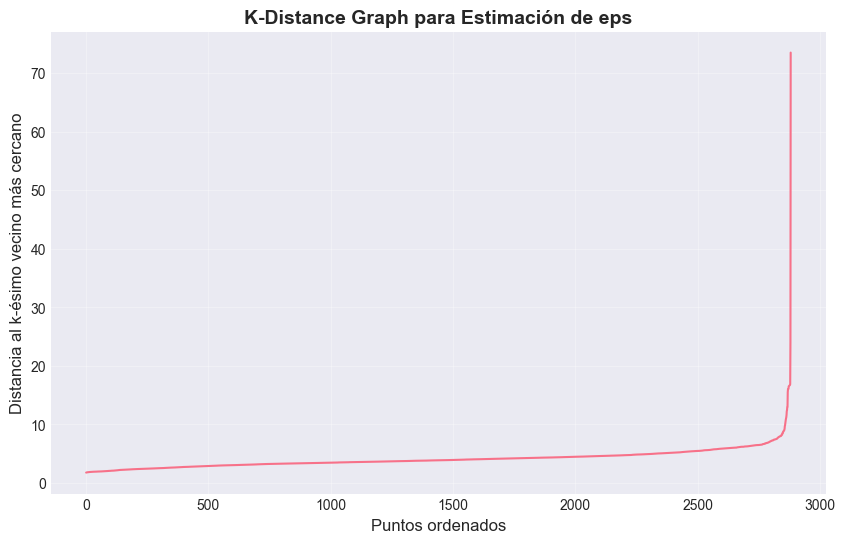


Rango sugerido para eps: 6.462 - 8.931


In [27]:
# Calcular k-distance graph para estimar eps
from sklearn.neighbors import NearestNeighbors

# Usar min_samples = 2 * dimensionalidad (regla general)
min_samples_rule = 2 * X.shape[1]
print(f"min_samples sugerido (2 * dim): {min_samples_rule}")

# Para dataset grande, usar muestra más pequeña
min_samples_options = [50, 100, 150]

print("\nCalculando k-distance graph...")
neighbors = NearestNeighbors(n_neighbors=100)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Ordenar distancias y graficar
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Puntos ordenados', fontsize=12)
plt.ylabel('Distancia al k-ésimo vecino más cercano', fontsize=12)
plt.title('K-Distance Graph para Estimación de eps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('../images/dbscan_k_distance.png', dpi=300, bbox_inches='tight')
plt.show()

# Estimar eps del gráfico (punto del codo)
print(f"\nRango sugerido para eps: {distances[int(len(distances)*0.95)]:.3f} - {distances[int(len(distances)*0.99)]:.3f}")

In [28]:
# Evaluar diferentes combinaciones de eps y min_samples
eps_range = [1.5, 2.0, 2.5, 3.0, 3.5]
min_samples_range = [50, 100, 150]

results = []

print("Evaluando DBSCAN con diferentes hiperparámetros...\n")
for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = dbscan.fit_predict(X)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Solo calcular métricas si hay al menos 2 clusters
        if n_clusters >= 2 and n_noise < len(labels) * 0.9:
            # Calcular métricas excluyendo ruido
            mask = labels != -1
            if np.sum(mask) > 0:
                sil = silhouette_score(X[mask], labels[mask])
                db = davies_bouldin_score(X[mask], labels[mask])
                ch = calinski_harabasz_score(X[mask], labels[mask])
            else:
                sil, db, ch = -1, np.inf, 0
        else:
            sil, db, ch = -1, np.inf, 0
        
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': n_noise/len(labels)*100,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })
        
        print(f"eps={eps:.1f}, min_samples={min_samples:3d} → "
              f"Clusters={n_clusters:2d}, Ruido={n_noise:4d} ({n_noise/len(labels)*100:5.1f}%), "
              f"Sil={sil:6.4f}, DB={db:6.4f}")

# Convertir a DataFrame
results_df = pd.DataFrame(results)
print("\n✓ Evaluación completada")

Evaluando DBSCAN con diferentes hiperparámetros...

eps=1.5, min_samples= 50 → Clusters= 1, Ruido=2736 ( 95.0%), Sil=-1.0000, DB=   inf
eps=1.5, min_samples=100 → Clusters= 0, Ruido=2881 (100.0%), Sil=-1.0000, DB=   inf
eps=1.5, min_samples=150 → Clusters= 0, Ruido=2881 (100.0%), Sil=-1.0000, DB=   inf
eps=2.0, min_samples= 50 → Clusters= 2, Ruido=2275 ( 79.0%), Sil=0.3545, DB=1.0661
eps=2.0, min_samples=100 → Clusters= 1, Ruido=2567 ( 89.1%), Sil=-1.0000, DB=   inf
eps=2.0, min_samples= 50 → Clusters= 2, Ruido=2275 ( 79.0%), Sil=0.3545, DB=1.0661
eps=2.0, min_samples=100 → Clusters= 1, Ruido=2567 ( 89.1%), Sil=-1.0000, DB=   inf
eps=2.0, min_samples=150 → Clusters= 0, Ruido=2881 (100.0%), Sil=-1.0000, DB=   inf
eps=2.5, min_samples= 50 → Clusters= 5, Ruido=1628 ( 56.5%), Sil=0.1922, DB=1.2696
eps=2.5, min_samples=100 → Clusters= 1, Ruido=2190 ( 76.0%), Sil=-1.0000, DB=   inf
eps=2.0, min_samples=150 → Clusters= 0, Ruido=2881 (100.0%), Sil=-1.0000, DB=   inf
eps=2.5, min_samples= 50 → 

In [29]:
# Encontrar mejor configuración
# Filtrar configuraciones con ruido razonable (<50%) y al menos 2 clusters
valid_results = results_df[(results_df['noise_pct'] < 50) & (results_df['n_clusters'] >= 2)]

if len(valid_results) > 0:
    # Ordenar por Silhouette Score (mayor es mejor)
    best_dbscan = valid_results.sort_values('silhouette', ascending=False).iloc[0]
    
    print("\nMejor configuración DBSCAN:")
    print(f"  eps: {best_dbscan['eps']}")
    print(f"  min_samples: {int(best_dbscan['min_samples'])}")
    print(f"  Clusters: {int(best_dbscan['n_clusters'])}")
    print(f"  Ruido: {int(best_dbscan['n_noise'])} ({best_dbscan['noise_pct']:.1f}%)")
    print(f"  Silhouette: {best_dbscan['silhouette']:.4f}")
    print(f"  Davies-Bouldin: {best_dbscan['davies_bouldin']:.4f}")
    print(f"  Calinski-Harabasz: {best_dbscan['calinski_harabasz']:.2f}")
else:
    print("\n⚠ No se encontraron configuraciones válidas. Ajustar rangos de eps y min_samples.")
    best_dbscan = results_df.iloc[0]  # Usar primera configuración como fallback


Mejor configuración DBSCAN:
  eps: 3.0
  min_samples: 50
  Clusters: 3
  Ruido: 931 (32.3%)
  Silhouette: 0.3408
  Davies-Bouldin: 1.2658
  Calinski-Harabasz: 981.55


### 4.2. Aplicar DBSCAN con Hiperparámetros Óptimos

In [30]:
# Aplicar DBSCAN con mejor configuración
best_eps = best_dbscan['eps']
best_min_samples = int(best_dbscan['min_samples'])

print(f"Aplicando DBSCAN con eps={best_eps}, min_samples={best_min_samples}...")
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples, n_jobs=-1)
dbscan_labels = dbscan_final.fit_predict(X)

# Calcular métricas finales
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

mask_dbscan = dbscan_labels != -1
if np.sum(mask_dbscan) > 0 and n_clusters_dbscan >= 2:
    dbscan_silhouette = silhouette_score(X[mask_dbscan], dbscan_labels[mask_dbscan])
    dbscan_davies_bouldin = davies_bouldin_score(X[mask_dbscan], dbscan_labels[mask_dbscan])
    dbscan_calinski_harabasz = calinski_harabasz_score(X[mask_dbscan], dbscan_labels[mask_dbscan])
else:
    dbscan_silhouette = -1
    dbscan_davies_bouldin = np.inf
    dbscan_calinski_harabasz = 0

print(f"\n✓ DBSCAN completado")
print(f"\nMétricas de Calidad:")
print(f"  Clusters identificados: {n_clusters_dbscan}")
print(f"  Puntos de ruido/outliers: {n_noise_dbscan:,} ({n_noise_dbscan/len(dbscan_labels)*100:.1f}%)")
print(f"  Silhouette Score: {dbscan_silhouette:.4f}")
print(f"  Davies-Bouldin Index: {dbscan_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Score: {dbscan_calinski_harabasz:.2f}")

print(f"\nDistribución de Clusters:")
unique, counts = np.unique(dbscan_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f"  Ruido: {count:,} observaciones ({count/len(dbscan_labels)*100:.1f}%)")
    else:
        print(f"  Cluster {cluster}: {count:,} observaciones ({count/len(dbscan_labels)*100:.1f}%)")

Aplicando DBSCAN con eps=3.0, min_samples=50...

✓ DBSCAN completado

Métricas de Calidad:
  Clusters identificados: 3
  Puntos de ruido/outliers: 931 (32.3%)
  Silhouette Score: 0.3408
  Davies-Bouldin Index: 1.2658
  Calinski-Harabasz Score: 981.55

Distribución de Clusters:
  Ruido: 931 observaciones (32.3%)
  Cluster 0: 326 observaciones (11.3%)
  Cluster 1: 1,118 observaciones (38.8%)
  Cluster 2: 506 observaciones (17.6%)

✓ DBSCAN completado

Métricas de Calidad:
  Clusters identificados: 3
  Puntos de ruido/outliers: 931 (32.3%)
  Silhouette Score: 0.3408
  Davies-Bouldin Index: 1.2658
  Calinski-Harabasz Score: 981.55

Distribución de Clusters:
  Ruido: 931 observaciones (32.3%)
  Cluster 0: 326 observaciones (11.3%)
  Cluster 1: 1,118 observaciones (38.8%)
  Cluster 2: 506 observaciones (17.6%)


### 4.3. Visualización de Clusters DBSCAN

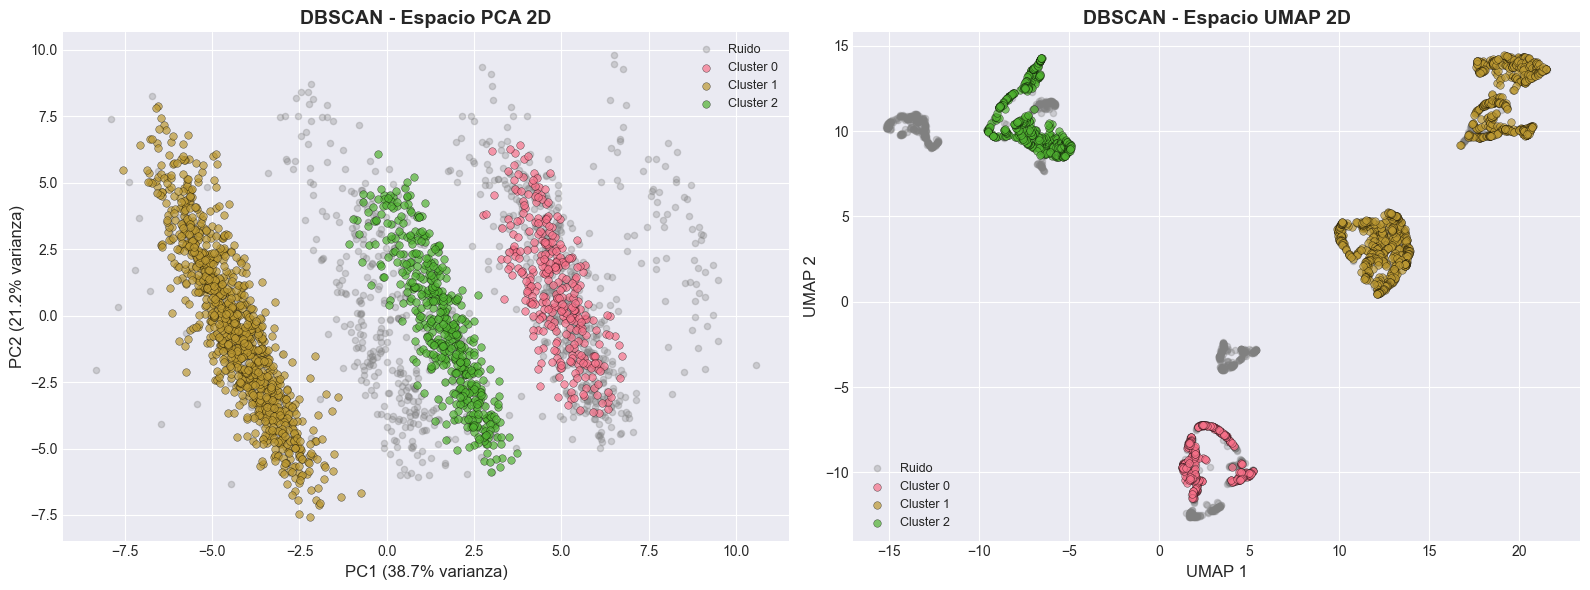

In [31]:
# Visualizar en PCA 2D y UMAP 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Crear colormap con gris para ruido
colors = plt.cm.viridis(np.linspace(0, 1, n_clusters_dbscan))
colors_with_noise = np.vstack([[0.5, 0.5, 0.5, 0.3], colors])  # Gris para ruido

# PCA 2D
for cluster in np.unique(dbscan_labels):
    mask = dbscan_labels == cluster
    if cluster == -1:
        axes[0].scatter(df_pca_2d.loc[mask, 'PC1'], df_pca_2d.loc[mask, 'PC2'],
                       c='gray', alpha=0.3, s=20, label='Ruido')
    else:
        axes[0].scatter(df_pca_2d.loc[mask, 'PC1'], df_pca_2d.loc[mask, 'PC2'],
                       alpha=0.7, s=30, edgecolors='k', linewidth=0.3, label=f'Cluster {cluster}')

axes[0].set_xlabel('PC1 (38.7% varianza)', fontsize=12)
axes[0].set_ylabel('PC2 (21.2% varianza)', fontsize=12)
axes[0].set_title(f'DBSCAN - Espacio PCA 2D', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)

# UMAP 2D
for cluster in np.unique(dbscan_labels):
    mask = dbscan_labels == cluster
    if cluster == -1:
        axes[1].scatter(df_umap_2d.loc[mask, 'UMAP1'], df_umap_2d.loc[mask, 'UMAP2'],
                       c='gray', alpha=0.3, s=20, label='Ruido')
    else:
        axes[1].scatter(df_umap_2d.loc[mask, 'UMAP1'], df_umap_2d.loc[mask, 'UMAP2'],
                       alpha=0.7, s=30, edgecolors='k', linewidth=0.3, label=f'Cluster {cluster}')

axes[1].set_xlabel('UMAP 1', fontsize=12)
axes[1].set_ylabel('UMAP 2', fontsize=12)
axes[1].set_title(f'DBSCAN - Espacio UMAP 2D', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig('../images/dbscan_clusters_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.4. Caracterización de Clusters DBSCAN

In [32]:
# Añadir labels a los datos con features
df_featured['Cluster_DBSCAN'] = dbscan_labels

# Caracterizar cada cluster (excluyendo ruido)
print("="*80)
print("CARACTERIZACIÓN DE CLUSTERS DBSCAN")
print("="*80)

for cluster_id in sorted(np.unique(dbscan_labels)):
    if cluster_id == -1:
        continue  # Omitir ruido por ahora
    
    cluster_data = df_featured[df_featured['Cluster_DBSCAN'] == cluster_id]
    n_obs = len(cluster_data)
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} (n={n_obs:,}, {n_obs/len(df_featured)*100:.1f}%)")
    print(f"{'='*80}")
    
    # Estadísticas de variables clave
    for var in key_vars:
        if var in cluster_data.columns:
            mean_val = cluster_data[var].mean()
            std_val = cluster_data[var].std()
            print(f"  {var:30s}: {mean_val:10.2f} ± {std_val:8.2f}")
    
    # Distribución temporal
    hora_dist = cluster_data['HORA'].value_counts().sort_index()
    hora_pico = hora_dist.idxmax()
    print(f"\n  Hora con más observaciones: {hora_pico}:00 ({hora_dist[hora_pico]} obs)")
    
    # Día de la semana
    if 'DIA_SEMANA' in cluster_data.columns:
        dia_dist = cluster_data['DIA_SEMANA'].value_counts()
        print(f"  Día más frecuente: Día {dia_dist.idxmax()} ({dia_dist.max()} obs)")

# Caracterizar ruido
if -1 in dbscan_labels:
    noise_data = df_featured[df_featured['Cluster_DBSCAN'] == -1]
    n_noise = len(noise_data)
    
    print(f"\n{'='*80}")
    print(f"RUIDO / OUTLIERS (n={n_noise:,}, {n_noise/len(df_featured)*100:.1f}%)")
    print(f"{'='*80}")
    print("\nEstos puntos representan patrones atípicos que no encajan en ningún cluster denso.")
    print("Posibles causas: eventos anómalos, transitorios, condiciones excepcionales.")

CARACTERIZACIÓN DE CLUSTERS DBSCAN

CLUSTER 0 (n=326, 11.3%)
  KWHD                          :      22.39 ±     1.84
  KVAD                          :      90.24 ±     7.28
  FACTOR_POTENCIA               :       0.99 ±     0.01
  VOLTAJE_PROM                  :   13360.69 ±    63.27
  CORRIENTE_PROM                :       1.58 ±     0.15
  THD_CORRIENTE_PROMEDIO        :       0.16 ±     0.04
  DESBALANCE_CORRIENTE          :       0.37 ±     0.04
  HORA                          :      11.58 ±     3.13

  Hora con más observaciones: 14:00 (44 obs)
  Día más frecuente: Día 3 (87 obs)

CLUSTER 1 (n=1,118, 38.8%)
  KWHD                          :       6.42 ±     1.06
  KVAD                          :      25.75 ±     4.35
  FACTOR_POTENCIA               :       1.00 ±     0.01
  VOLTAJE_PROM                  :   13393.12 ±    80.71
  CORRIENTE_PROM                :       0.00 ±     0.00
  THD_CORRIENTE_PROMEDIO        :       0.36 ±     0.06
  DESBALANCE_CORRIENTE          :       0.00 

## 5. Comparación de Algoritmos

In [33]:
# Tabla comparativa
comparison = pd.DataFrame({
    'Métrica': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Score', 
                'Número de Clusters', 'Puntos de Ruido'],
    'K-means': [f'{kmeans_silhouette:.4f}', f'{kmeans_davies_bouldin:.4f}', 
                f'{kmeans_calinski_harabasz:.2f}', optimal_k, 0],
    'DBSCAN': [f'{dbscan_silhouette:.4f}', f'{dbscan_davies_bouldin:.4f}', 
               f'{dbscan_calinski_harabasz:.2f}', n_clusters_dbscan, n_noise_dbscan]
})

print("\n" + "="*80)
print("COMPARACIÓN DE ALGORITMOS DE CLUSTERING")
print("="*80)
print(comparison.to_string(index=False))
print("\n" + "="*80)

print("\nConclusiones:")
print("\nK-means:")
print("  + Identifica clusters esféricos bien definidos")
print("  + Asigna todos los puntos a un cluster")
print("  + Interpretación clara y simétrica")
print("  - Asume clusters de forma convexa")
print("  - Sensible a outliers")

print("\nDBSCAN:")
print("  + Identifica clusters de forma arbitraria")
print("  + Detecta outliers automáticamente")
print("  + No requiere especificar k a priori")
print("  - Sensible a variaciones de densidad")
print("  - Hiperparámetros requieren ajuste cuidadoso")


COMPARACIÓN DE ALGORITMOS DE CLUSTERING
                Métrica K-means DBSCAN
       Silhouette Score  0.3065 0.3408
   Davies-Bouldin Index  1.3579 1.2658
Calinski-Harabasz Score 1297.43 981.55
     Número de Clusters       2      3
        Puntos de Ruido       0    931


Conclusiones:

K-means:
  + Identifica clusters esféricos bien definidos
  + Asigna todos los puntos a un cluster
  + Interpretación clara y simétrica
  - Asume clusters de forma convexa
  - Sensible a outliers

DBSCAN:
  + Identifica clusters de forma arbitraria
  + Detecta outliers automáticamente
  + No requiere especificar k a priori
  - Sensible a variaciones de densidad
  - Hiperparámetros requieren ajuste cuidadoso


## 6. Exportación de Resultados

In [34]:
# Guardar datos con labels de clustering
output_path = Path.cwd().parent / 'data' / 'clustered_data.csv'
df_featured.to_csv(output_path, index=False)

print(f"✓ Datos con clusters exportados a: {output_path}")
print(f"  Dimensiones: {df_featured.shape}")
print(f"  Columnas añadidas: Cluster_KMeans, Cluster_DBSCAN")

✓ Datos con clusters exportados a: d:\Desktop\Proyecto no supervizado\data\clustered_data.csv
  Dimensiones: (2881, 57)
  Columnas añadidas: Cluster_KMeans, Cluster_DBSCAN


## 7. Conclusiones del Análisis de Clustering

### Resumen de Resultados

Se aplicaron dos algoritmos de clustering complementarios:

**K-means:**
- Identificó patrones de consumo basados en similitud euclidiana
- Clusters representan niveles de carga y perfiles operativos
- Útil para segmentación clara y balanceada

**DBSCAN:**
- Detectó regiones de alta densidad en el espacio de features
- Identificó outliers y eventos anómalos
- Clusters reflejan patrones naturales sin asumir geometría específica

### Datos Generados

Los clusters identificados están disponibles en el archivo clustered_data.csv con las etiquetas:
- Cluster_KMeans: Asignación de K-means
- Cluster_DBSCAN: Asignación de DBSCAN (-1 indica anomalías)